# QEpy MD + Wavefunction Diagnostics

This notebook runs a short Andersen MD trajectory with QEpy and logs:
- potential/kinetic energy per atom
- KS eigenvalues at a selected k-point
- a two-band KS gap
- same-band wavefunction overlap magnitude/phase between consecutive MD steps

The goal is to show how to combine ASE MD control with QEpy electronic diagnostics.

In [ ]:
# --- optional pip installs (normally leave collapsed / do not run) ---
!pip install qepy f90wrap==0.2.16
!pip install dftpy
!pip install matplotlib

## Imports and runtime dependencies

This notebook uses:
- `ASE` for MD and trajectory handling
- `QEpyCalculator` for forces/energies/electronic data
- `NumPy` for array math
- `matplotlib` for plotting

In [30]:
import itertools

import numpy as np
from ase import units
from ase.build import molecule
from ase.md.andersen import Andersen
from ase.md.velocitydistribution import MaxwellBoltzmannDistribution
from qepy.calculator import QEpyCalculator
from qepy.io import QEInput

## Build atoms, calculator, and MD engine

This block:
1. builds a stretched-H₂O molecule with ASE
2. populates `qe_options`' geometry (cell/positions/`nat`/`ntyp`) from that atoms object via `QEInput.update_atoms`
3. creates the QEpy calculator and attaches it to the atoms
4. initializes velocities at target temperature
5. creates Andersen dynamics
6. allocates buffers for time-series data

`qe_options` below sets the SCF/electronics/pseudopotential namelists only. The geometry itself — a water molecule with one O–H bond stretched from its ~0.97 Å equilibrium to ~1.5 Å — is built with ASE right after and merged in via `QEInput.update_atoms`, so the MD run below has interesting bond dynamics and orbital reorganization to track.

In [31]:
# QE options for the stretched-H2O AIMD run. Geometry (nat/ntyp/cell/positions)
# is filled in below from the ASE atoms object via QEInput.update_atoms.
qe_options = {
    "&control": {
        "calculation": "'scf'",
        "restart_mode": "'from_scratch'",
        "disk_io": "'none'",
        "pseudo_dir": "'./data/'",
    },
    "&system": {
        "nbnd": 10,
        "ecutwfc": 40,
        "occupations": "'smearing'",
        "degauss": 0.001,
        "smearing": "'gaussian'",
        "nosym": True,
    },
    "&electrons": {
        "electron_maxstep": 100,
        "conv_thr": 1e-6,
        "mixing_beta": 0.7,
        "diago_thr_init": 1.0e-4,
        "diago_david_ndim": 2,
    },
    "atomic_species": [
        "O  15.999   O_ONCV_PBE-1.2.upf",
        "H  1.008    H_ONCV_PBE-1.2.upf",
    ],
    # qepy's input writer iterates over each section's value, so use an empty
    # list for gamma — the section name "k_points gamma" already encodes it.
    "k_points gamma": [],
}

In [32]:
# Deterministic thermostat randomness for reproducible demo runs.
np.random.seed(2020)
comm = None

# Build a stretched-H2O molecule: one O-H bond pulled from ~0.97 Å to ~1.5 Å,
# in an 8x8x8 Å box (a vacuum-embedded "molecule" for a plane-wave code).
# ASE's molecule("H2O") orders atoms as O, H, H (indices 0, 1, 2).
atoms = molecule("H2O")
atoms.set_distance(0, 1, 1.5, fix=0)
atoms.set_cell([8.0, 8.0, 8.0])
atoms.center()
atoms.pbc = True

# Fill in qe_options' geometry (cell/positions/nat/ntyp) from the atoms object.
qe_options = QEInput().update_atoms(atoms, qe_options=qe_options)

# Build QEpy calculator directly from qe_options.
calc = QEpyCalculator(comm=comm, qe_options=qe_options, logfile="tmp.out")
atoms.calc = calc

# Initialize velocities and MD integrator/thermostat.
MaxwellBoltzmannDistribution(atoms, temperature_K=300.0, force_temp=True)
dyn = Andersen(atoms, 0.5 * units.fs, temperature_K=300.0, andersen_prob=0.02)

# Bands tracked for electronic diagnostics in stretched-H2O:
#   2 = sigma(O-H) bonding    3 = O lone pair    4 = sigma*_OH (LUMO)
bands = (2, 3, 4)
kpt = 0

# Buffers for time series and wavefunction-derived observables.
steps_md = []
epot_pa = []
ekin_pa = []
oh_d1 = []   # O - H1 bond length (Å), the stretched bond at t=0
oh_d2 = []   # O - H2 bond length (Å), the spectator bond at t=0
wf_rows = []
psi_prev = {b: None for b in bands}   # previous-step wavefunctions (consecutive overlap)
md_step = {"i": 0}

## Overlap metric definition

`overlap(prev, cur)` computes same-band overlap between consecutive MD steps:
- magnitude: electronic-state continuity indicator
- phase: gauge/phase evolution indicator

ONCV (norm-conserving) pseudo-wavefunctions are already normalized and orthogonal across bands, so the raw inner product is used directly — no extra normalization needed.

In [33]:
def overlap(prev, cur):
    """Return overlap magnitude and phase between two same-band wavefunctions."""
    if prev is None:
        return np.nan, np.nan
    ov = np.sum(np.conjugate(prev) * cur)
    return float(np.abs(ov)), float(np.angle(ov))

## Per-step data collection callback

`wf_step()` is called every MD step and records:
- per-atom energies
- selected eigenvalues and optional two-band gap
- same-band overlap metrics using current vs previous wavefunctions

In [34]:
def wf_step():
    # Called by ASE every MD step.
    a = dyn.atoms
    s = md_step["i"]; md_step["i"] += 1
    n = len(a)

    # Store basic thermodynamic observables per atom.
    steps_md.append(s)
    epot_pa.append(float(a.get_potential_energy() / n))
    ekin_pa.append(float(a.get_kinetic_energy() / n))

    # Track both O-H bond lengths in Å (mic=True respects the periodic box).
    # Atom 0 is O; atoms 1/2 are the stretched/spectator H's (see build cell).
    oh_d1.append(float(a.get_distance(0, 1, mic=True)))
    oh_d2.append(float(a.get_distance(0, 2, mic=True)))

    # Only root rank writes wavefunction/eigenvalue diagnostics.
    if not getattr(a.calc, "is_root", True):
        return

    # KS eigenvalues at the selected k-point.
    eps = calc.get_eigenvalues(kpt=kpt)
    row = {"step": s, **{f"eval_b{b}": float(eps[b]) for b in bands}}

    # Emit every pairwise gap among the tracked bands so the plot cell can
    # choose which to display (HOMO–LUMO, σ→σ*, virtual–virtual, etc.).
    for b0, b1 in itertools.combinations(sorted(bands), 2):
        row[f"gap_b{b1}_b{b0}"] = float(eps[b1] - eps[b0])

    # Wavefunctions are returned in the same order as `bands`.
    psi_list = calc.get_wave_function(kpt=kpt, band=bands)
    for b, psi_b in zip(bands, psi_list):
        # Consecutive-step overlap magnitude/phase.
        mag, ph = overlap(psi_prev[b], psi_b)
        row[f"ovl_abs_b{b}"] = mag
        row[f"ovl_phase_b{b}"] = ph
        psi_prev[b] = psi_b

    wf_rows.append(row)

## Run dynamics

Run the MD loop and collect the per-step wavefunction diagnostics into `wf_cols` (one list per quantity), used directly by the sanity check and plots below.

In [35]:

# Run MD, recording custom observables each step.
dyn.attach(wf_step, interval=1)
dyn.run(20)

# Eigenvalue/gap/overlap diagnostics as a dict of per-key lists (every row
# has the same keys), used directly below by the plots.
wf_cols = {}
if wf_rows:
    for key in wf_rows[0]:
        wf_cols[key] = [r[key] for r in wf_rows]

## Plot diagnostics

Panels show: total energy per atom, O-H bond lengths, same-band overlap magnitude, KS eigenvalues, and KS gaps between the tracked bands.

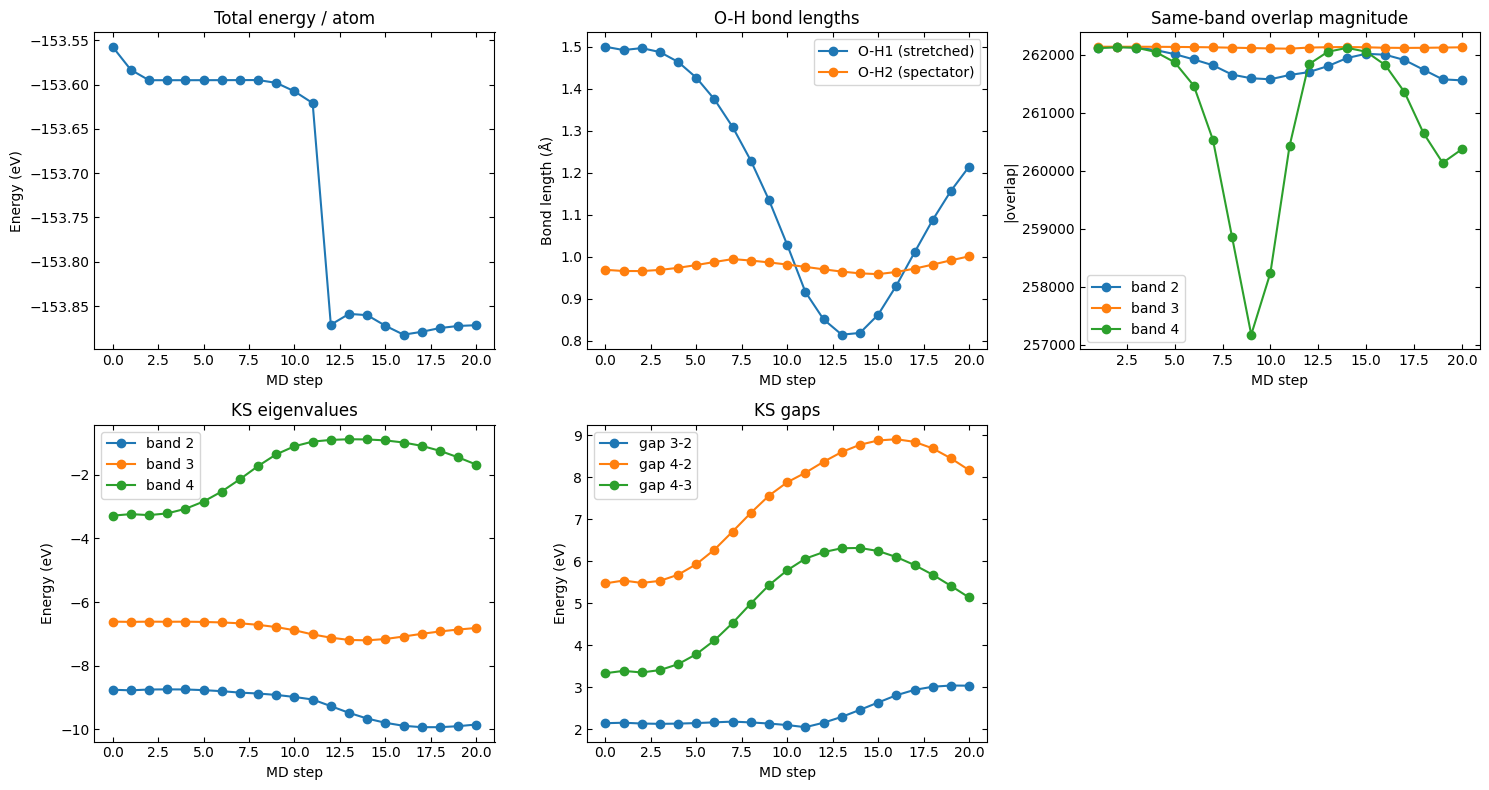

In [36]:
import matplotlib.pyplot as plt

sw = steps_md
swf = wf_cols["step"]
etot_pa = [pe + ke for pe, ke in zip(epot_pa, ekin_pa)]  # total energy/atom (eV)

fig, axs = plt.subplots(2, 3, figsize=(15, 8))

axs[0, 0].plot(sw, etot_pa, marker="o")
axs[0, 0].set(title="Total energy / atom", xlabel="MD step", ylabel="Energy (eV)")

axs[0, 1].plot(sw, oh_d1, marker="o", label="O-H1 (stretched)")
axs[0, 1].plot(sw, oh_d2, marker="o", label="O-H2 (spectator)")
axs[0, 1].set(title="O-H bond lengths", xlabel="MD step", ylabel="Bond length (Å)")
axs[0, 1].legend()

for b in bands:
    axs[0, 2].plot(swf, wf_cols[f"ovl_abs_b{b}"], marker="o", label=f"band {b}")
axs[0, 2].set(title="Same-band overlap magnitude", xlabel="MD step", ylabel="|overlap|")
axs[0, 2].legend()

for b in bands:
    axs[1, 0].plot(swf, wf_cols[f"eval_b{b}"], marker="o", label=f"band {b}")
axs[1, 0].set(title="KS eigenvalues", xlabel="MD step", ylabel="Energy (eV)")
axs[1, 0].legend()

for b0, b1 in itertools.combinations(sorted(bands), 2):
    axs[1, 1].plot(swf, wf_cols[f"gap_b{b1}_b{b0}"], marker="o", label=f"gap {b1}-{b0}")
axs[1, 1].set(title="KS gaps", xlabel="MD step", ylabel="Energy (eV)")
axs[1, 1].legend()

axs[1, 2].axis("off")

plt.tight_layout()
plt.show()